# Pre-process — Build Urban-Core AOIs from CHN Level-3 Districts

This notebook prepares the analysis area used by the downstream Earth Engine and Colab books. It runs in Google Colab because it reads local/Drive shapefiles, accesses public ESA WorldCover rasters through `/vsicurl/`, and exports a GeoJSON and zipped shapefile for Google Earth Engine ingestion.

**Input**: `CHN_level3_2024` Level-3 Chinese administrative districts in Google Drive.  
**Output**: `urban_cores_by_builtup.geojson`, `urban_cores_by_builtup_shp.zip`, a summary CSV, and a diagnostic map.  
**Runtime**: typically 5-15 minutes in Colab, depending on raster access speed.  
**Role in the pipeline**: defines the shared urban-core AOI for Book 0 and Book 1, avoiding oversized full-municipality polygons.


### Step 1: Install geospatial dependencies

**Purpose**: Install the Python geospatial stack required to read shapefiles, handle vector geometries, and stream WorldCover raster tiles.  
**Input**: Colab runtime.  
**Output**: `geopandas`, `rasterio`, `shapely`, `fiona`, and `pyogrio` available for the remaining cells.


In [ ]:
!pip -q install geopandas rasterio shapely fiona pyogrio


### Step 2: Mount Google Drive

**Purpose**: Connect the Colab runtime to the project files stored under `MyDrive/0069/week10`.  
**Input**: Google Drive authentication.  
**Output**: `/content/drive` mounted so the notebook can read raw boundaries and save processed AOIs.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 3: Define project paths and city-code filters

**Purpose**: Set the raw-data location, output directory, built-up threshold, and GB/T administrative-code prefixes for the ten study cities.  
**Input**: Drive folder structure and the `CHN_level3_2024` shapefile path.  
**Output**: reusable path variables and city-code filters for the AOI selection workflow.


In [ ]:
from pathlib import Path

L3_PATH = Path('/content/drive/MyDrive/0069/week10/data/raw/CHN_level3_2024.shp')
OUTPUT_DIR = Path('/content/drive/MyDrive/0069/week10/data/processed/city_districts')

# Filter by 6-digit GB/T 2260 administrative code (区划码) prefix.
# Handles direct municipalities and 直筒子 cities uniformly.
TARGET_CITY_CODE_PREFIXES = {
    'guangzhou':  ['4401'],
    'shenzhen':   ['4403'],
    'dongguan':   ['4419'],
    'beijing':    ['1101'],
    'tianjin':    ['1201'],
    'shanghai':   ['3101'],
    'chongqing':  ['5001', '5002'],
    'chengdu':    ['5101'],
    'wuhan':      ['4201'],
    'xian':       ['6101'],
}
CODE_COLUMN = '区划码'
BUILTUP_THRESHOLD = 0.20

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('L3 file exists:', L3_PATH.exists())
print('Output dir:', OUTPUT_DIR)

L3 file exists: True
Output dir: /content/drive/MyDrive/0069/week10/data/processed/city_districts


### Step 4: Load and subset CHN Level-3 districts

**Purpose**: Read the national district layer and keep only districts belonging to the ten selected cities.  
**Input**: `CHN_level3_2024.shp` and the city-code prefix dictionary.  
**Output**: a district GeoDataFrame with harmonised city names and an English-name fallback field for diagnostics.


In [ ]:
import geopandas as gpd
import pandas as pd

gdf = gpd.read_file(L3_PATH)
print(f'Total districts in CHN_level3_2024: {len(gdf)}')
gdf[CODE_COLUMN] = gdf[CODE_COLUMN].astype(str).str.strip()

parts = []
for city_key, prefixes in TARGET_CITY_CODE_PREFIXES.items():
    mask = pd.Series(False, index=gdf.index)
    for prefix in prefixes:
        mask = mask | gdf[CODE_COLUMN].str.startswith(prefix)
    sub = gdf[mask].copy()
    sub['city'] = city_key
    parts.append(sub)
    print(f'  {city_key:>10s}: {len(sub):3d} districts  (prefixes={prefixes})')

districts = pd.concat(parts, ignore_index=True)
districts = gpd.GeoDataFrame(districts, geometry='geometry', crs=gdf.crs)
if str(districts.crs).upper() != 'EPSG:4326':
    districts = districts.to_crs('EPSG:4326')

# Strip stray whitespace / CR chars
for col in ['NAME_3', 'NAME_2', 'NAME_1', 'ENG_NAME', '地名']:
    if col in districts.columns:
        districts[col] = districts[col].astype(str).str.strip().str.strip('\r').str.strip()

# Unified English name with fallback chain. Handles direct-municipality
# districts (NAME_3 valid) AND 直筒子 cities like Dongguan (NAME_3='NULL',
# fall back to NAME_2='Dongguan').
def pick_english_name(row):
    for col in ['NAME_3', 'NAME_2', 'ENG_NAME', '地名']:
        if col in row.index:
            v = str(row[col]).strip()
            if v and v.upper() not in ('NULL', 'NAN', 'NONE'):
                return v
    return ''
districts['name_en'] = districts.apply(pick_english_name, axis=1)

print(f'\nTotal districts to evaluate: {len(districts)}')
print('\nFirst 5 rows with English vs Chinese names:')
print(districts[['city', 'name_en', '地名']].head(5).to_string(index=False))

Total districts in CHN_level3_2024: 2853
   guangzhou:  11 districts  (prefixes=['4401'])
    shenzhen:   9 districts  (prefixes=['4403'])
    dongguan:   1 districts  (prefixes=['4419'])
     beijing:  16 districts  (prefixes=['1101'])
     tianjin:  16 districts  (prefixes=['1201'])
    shanghai:  16 districts  (prefixes=['3101'])
   chongqing:  38 districts  (prefixes=['5001', '5002'])
     chengdu:  20 districts  (prefixes=['5101'])
       wuhan:  13 districts  (prefixes=['4201'])
        xian:  13 districts  (prefixes=['6101'])

Total districts to evaluate: 153

First 5 rows with English vs Chinese names:
     city name_en  地名
guangzhou Conghua 从化区
guangzhou   Panyu 番禺区
guangzhou  Haizhu 海珠区
guangzhou   Huadu 花都区
guangzhou Huangpu 黄埔区


### Step 5: Define WorldCover built-up fraction helpers

**Purpose**: Identify which ESA WorldCover tiles intersect each district and define a raster-based function for estimating built-up share.  
**Input**: district geometries and public WorldCover 2021 raster URLs.  
**Output**: helper functions that return the fraction of valid 10 m pixels classified as built-up.


In [ ]:
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from shapely.geometry import mapping

WC_URL_TEMPLATE = (
    '/vsicurl/https://esa-worldcover.s3.eu-central-1.amazonaws.com/'
    'v200/2021/map/ESA_WorldCover_10m_2021_v200_{tile_id}_Map.tif'
)
WC_CLASS_BUILTUP = 50
WC_CLASS_NODATA = 0

def get_overlapping_tile_ids(geom):
    minx, miny, maxx, maxy = geom.bounds
    x0 = int(np.floor(minx / 3.0) * 3)
    x1 = int(np.floor(maxx / 3.0) * 3)
    y0 = int(np.floor(miny / 3.0) * 3)
    y1 = int(np.floor(maxy / 3.0) * 3)
    tiles = []
    for x in range(x0, x1 + 3, 3):
        for y in range(y0, y1 + 3, 3):
            lat_h = 'N' if y >= 0 else 'S'
            lon_h = 'E' if x >= 0 else 'W'
            tiles.append(f'{lat_h}{abs(y):02d}{lon_h}{abs(x):03d}')
    return tiles

def builtup_fraction_for_geom(geom):
    tile_ids = get_overlapping_tile_ids(geom)
    total_valid = 0
    total_builtup = 0
    geom_geojson = [mapping(geom)]
    for tile_id in tile_ids:
        url = WC_URL_TEMPLATE.format(tile_id=tile_id)
        try:
            with rasterio.open(url) as src:
                out_image, _ = rio_mask(src, geom_geojson, crop=True, nodata=WC_CLASS_NODATA)
                data = out_image[0]
                valid = (data != WC_CLASS_NODATA) & (data != 255)
                total_valid += int(valid.sum())
                total_builtup += int((data == WC_CLASS_BUILTUP).sum())
        except Exception as exc:
            msg = str(exc).lower()
            if 'not exist' in msg or '404' in msg or 'no such file' in msg:
                continue
            print(f'    WARN tile {tile_id}: {exc}')
    if total_valid == 0:
        return None
    return total_builtup / total_valid

all_tiles = set()
for g in districts.geometry:
    all_tiles.update(get_overlapping_tile_ids(g))
print(f'Unique WorldCover tiles touched: {len(all_tiles)}')
print(sorted(all_tiles))

Unique WorldCover tiles touched: 17
['N21E111', 'N21E114', 'N27E105', 'N27E108', 'N27E114', 'N30E102', 'N30E105', 'N30E108', 'N30E111', 'N30E114', 'N30E120', 'N33E105', 'N33E108', 'N36E114', 'N36E117', 'N39E114', 'N39E117']


### Step 6: Compute built-up fraction for every district

**Purpose**: Quantify how urban each Level-3 district is, using WorldCover built-up pixels as an objective filter.  
**Input**: selected district geometries and the WorldCover helper function.  
**Output**: a `builtup_frac` column used to retain urban-core districts and drop peripheral rural/mountain districts.


In [ ]:
import time

print('Computing built-up fraction per district (via /vsicurl/, no auth)...')
fractions = []
t0 = time.time()

for i, (idx, row) in enumerate(districts.iterrows(), start=1):
    frac = builtup_fraction_for_geom(row.geometry)
    fractions.append(frac)
    if i % 10 == 0 or i == len(districts):
        print(f'  {i:3d}/{len(districts)} done  ({time.time()-t0:.0f}s)')

districts['builtup_frac'] = [float(x) if x is not None else None for x in fractions]
print(f'\nTotal time: {time.time()-t0:.0f}s')

print('\nDistrict-level built-up fractions (English names):')
print(
    districts[['city', 'name_en', 'builtup_frac']]
    .sort_values(['city', 'builtup_frac'], ascending=[True, False])
    .to_string(index=False)
)

Computing built-up fraction per district (via /vsicurl/, no auth)...
   10/153 done  (15s)
   20/153 done  (20s)
   30/153 done  (39s)
   40/153 done  (54s)
   50/153 done  (67s)
   60/153 done  (77s)
   70/153 done  (86s)
   80/153 done  (112s)
   90/153 done  (132s)
  100/153 done  (156s)
  110/153 done  (178s)
  120/153 done  (188s)
  130/153 done  (202s)
  140/153 done  (213s)
  150/153 done  (222s)
  153/153 done  (230s)

Total time: 230s

District-level built-up fractions (English names):
     city                  name_en  builtup_frac
  beijing                  Xicheng      0.794578
  beijing                Dongcheng      0.773392
  beijing                  Fengtai      0.560075
  beijing                 Chaoyang      0.556109
  beijing              Shijingshan      0.507646
  beijing                  Haidian      0.447620
  beijing                   Shunyi      0.295611
  beijing                 Tongzhou      0.293805
  beijing                   Daxing      0.273708
  beijing 

### Step 7: Select urban-core districts and summarise coverage

**Purpose**: Apply the built-up threshold and produce a city-level summary of kept and dropped districts.  
**Input**: district built-up fractions.  
**Output**: `selected` AOI features and a summary table reporting retained district counts per city.


In [ ]:
selected = districts[
    (districts['builtup_frac'].notna()) &
    (districts['builtup_frac'] >= BUILTUP_THRESHOLD)
].copy()
print(f'Kept {len(selected)} of {len(districts)} districts (threshold = {BUILTUP_THRESHOLD})')

summary_rows = []
for city_key in TARGET_CITY_CODE_PREFIXES:
    sub_all = districts[districts['city'] == city_key]
    sub_kept = selected[selected['city'] == city_key]
    kept_names_en = ', '.join(sub_kept['name_en'].astype(str).tolist())
    summary_rows.append({
        'city': city_key,
        'n_total': len(sub_all),
        'n_kept': len(sub_kept),
        'mean_builtup_frac_all': float(sub_all['builtup_frac'].mean()) if len(sub_all) else None,
        'districts_kept': kept_names_en,
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

Kept 84 of 153 districts (threshold = 0.2)


,city,n_total,n_kept,mean_builtup_frac_all,districts_kept
0,guangzhou,11,9,0.376188,"Panyu, Haizhu, Huadu, Huangpu, Liwan, Nansha, ..."
1,shenzhen,9,9,0.370356,"Baoan, Futian, Longgang, Luohu, Yantian, Longh..."
2,dongguan,1,1,0.409047,Dongguan
3,beijing,16,9,0.320855,"Daxing, Dongcheng, Fengtai, Haidian, Shijingsh..."
4,tianjin,16,11,0.454302,"Beichen, Binhaixin, Dongli, Hebei, Hexi, Hongq..."
5,shanghai,16,15,0.528941,"Fengxian, Hongkou, Huangpu, Jiading, Jinshan, ..."
6,chongqing,38,6,0.069848,"Dadukou, Jiulongpo, Nanan, Shapingba, Yuzhong,..."
7,chengdu,20,9,0.236774,"Chenghua, Jinniu, Jinjiang, Pidu, Qingyang, Sh..."
8,wuhan,13,7,0.332048,"Hanyang, Hongshan, Jiangan, Jianghan, Qiaokou,..."
9,xian,13,8,0.388169,"Baqiao, Beilin, Gaoling, Lianhu, Weiyang, Yanl..."


### Step 8: Export AOI files for downstream notebooks and GEE

**Purpose**: Save the selected urban-core districts in formats required by both Colab and Google Earth Engine.  
**Input**: the filtered district GeoDataFrame and summary table.  
**Output**: GeoJSON, CSV, shapefile folder, and zipped shapefile for upload to GEE Assets.


In [ ]:
import shutil

keep_cols = [c for c in
             ['city', CODE_COLUMN, 'name_en', 'NAME_3', 'NAME_2',
              'TYPE_3', 'NAME_1', '地名', 'builtup_frac', 'geometry']
             if c in selected.columns]
selected_out = selected[keep_cols]

out_geojson = OUTPUT_DIR / 'urban_cores_by_builtup.geojson'
out_summary = OUTPUT_DIR / 'urban_cores_by_builtup_summary.csv'
out_shp_dir = OUTPUT_DIR / 'urban_cores_by_builtup_shp'

out_shp_dir.mkdir(parents=True, exist_ok=True)
selected_out.to_file(out_geojson, driver='GeoJSON')
summary_df.to_csv(out_summary, index=False)
selected_out.to_file(out_shp_dir / 'urban_cores_by_builtup.shp')
shutil.make_archive(str(OUTPUT_DIR / 'urban_cores_by_builtup_shp'), 'zip', str(out_shp_dir))

print('Saved:')
print(f'  {out_geojson}')
print(f'  {out_summary}')
print(f'  {OUTPUT_DIR / "urban_cores_by_builtup_shp.zip"}  <-- upload to GEE Assets')

/tmp/ipykernel_1240/1345354846.py:16: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  selected_out.to_file(out_shp_dir / 'urban_cores_by_builtup.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'builtup_frac' to 'builtup_fr'
  ogr_write(


Saved:
  /content/drive/MyDrive/0069/week10/data/processed/city_districts/urban_cores_by_builtup.geojson
  /content/drive/MyDrive/0069/week10/data/processed/city_districts/urban_cores_by_builtup_summary.csv
  /content/drive/MyDrive/0069/week10/data/processed/city_districts/urban_cores_by_builtup_shp.zip  <-- upload to GEE Assets


### Step 9: Plot the urban-core selection map

**Purpose**: Create a visual sanity check showing retained and dropped districts for each city.  
**Input**: all candidate districts, the selected subset, and the built-up threshold.  
**Output**: `urban_cores_by_builtup_map.png`, used later as a methods/diagnostic figure.


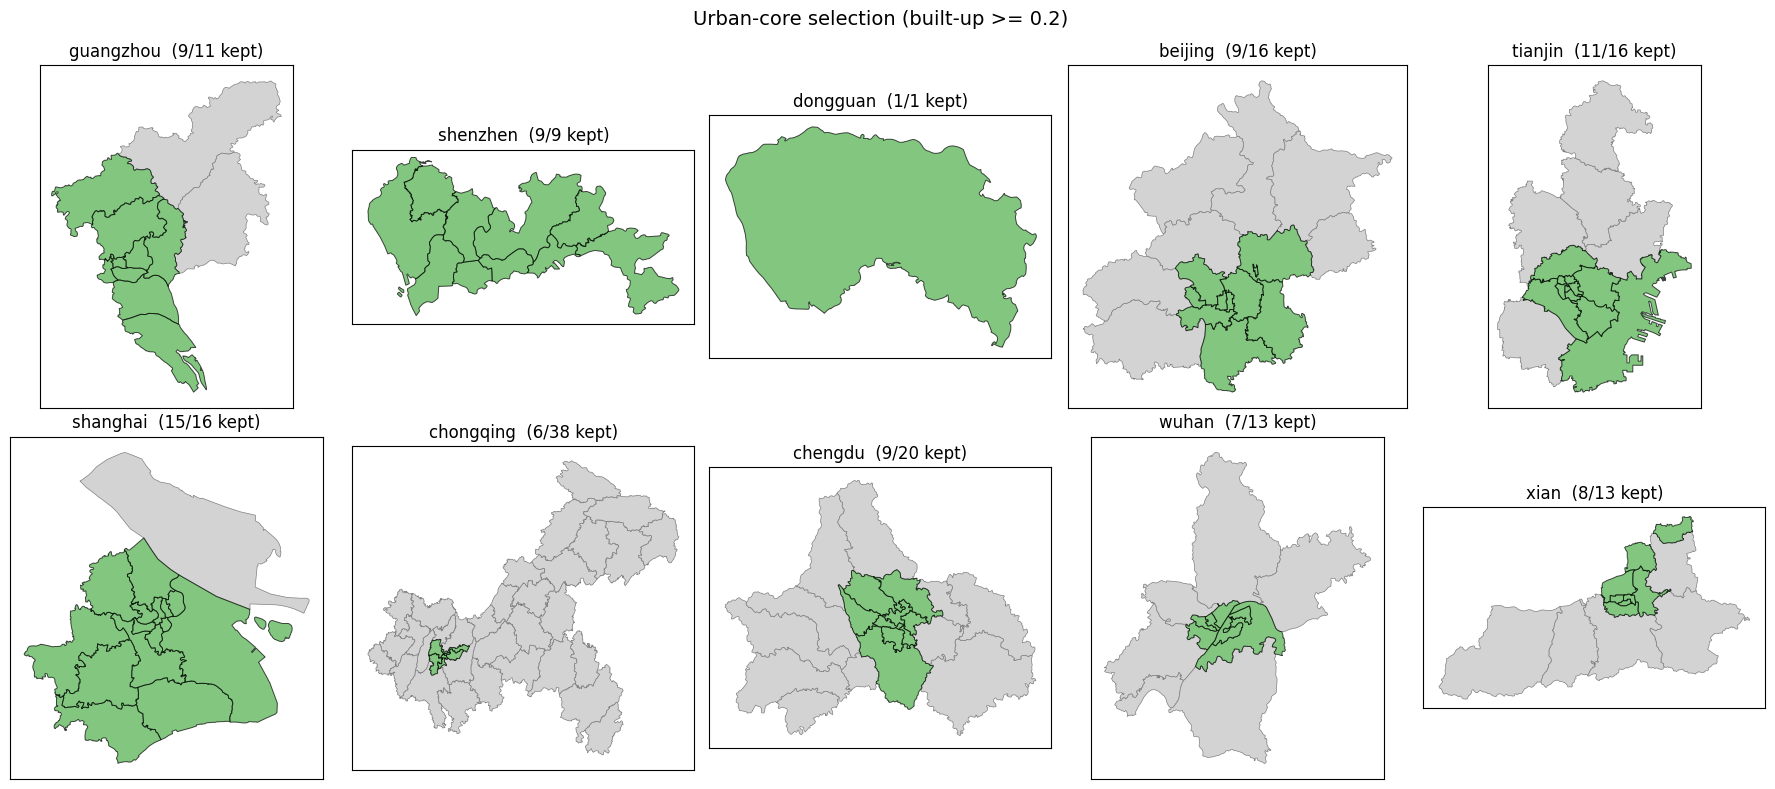

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, city_key in zip(axes.flatten(), TARGET_CITY_CODE_PREFIXES):
    sub = districts[districts['city'] == city_key]
    kept = sub[sub['builtup_frac'] >= BUILTUP_THRESHOLD]
    dropped = sub[sub['builtup_frac'] < BUILTUP_THRESHOLD]
    if len(dropped) > 0:
        dropped.plot(ax=ax, color='lightgray', edgecolor='gray', linewidth=0.5)
    if len(kept) > 0:
        kept.plot(ax=ax, color='#4daf4a', edgecolor='black', linewidth=0.7, alpha=0.7)
    ax.set_title(f'{city_key}  ({len(kept)}/{len(sub)} kept)')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'Urban-core selection (built-up >= {BUILTUP_THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'urban_cores_by_builtup_map.png', dpi=150, bbox_inches='tight')
plt.show()

## Manual handoff to Book 0 and Book 1

Upload `urban_cores_by_builtup_shp.zip` to Google Earth Engine as the AOI asset used by Book 1. Keep the GeoJSON version in Drive because Book 0 uses the same polygon layer to clip OSM candidates and roads. This ensures the OSM weak-label source and the EO feature grid are spatially aligned.
